# Clasificación vs Regresión — Predicción de Aprobación de Préstamos

**Proyecto de análisis de datos / Machine Learning**

Este notebook resuelve el taller paso a paso. Cada sección explica **qué** se hace y **por qué**, de modo que el código sea entendible y justificado, no solo ejecutable.

El dataset (`train_tarea.csv`) contiene información de solicitantes de préstamos. El objetivo es predecir si un préstamo fue **aprobado (Y)** o **rechazado (N)**.

## 0. Librerías

Importamos todo lo necesario al inicio:
- **pandas / numpy**: manipulación de datos.
- **matplotlib / seaborn**: gráficos para el EDA.
- **scikit-learn**: división de datos, codificación, modelos y métricas.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## Parte 1 — Comprensión del problema

**Variable objetivo (target):** `Loan_Status`, con dos valores posibles: `Y` (aprobado) y `N` (rechazado).

**¿Clasificación o regresión?** Es **clasificación binaria**. La razón: el target es una **categoría discreta** (aprobado / no aprobado), no un número continuo. La regresión predice cantidades numéricas; aquí asignamos cada solicitante a una de dos clases.

**Contexto:** una entidad financiera quiere automatizar la decisión de aprobar o negar préstamos según el perfil del solicitante (ingresos, historial crediticio, monto pedido, estado civil, educación, etc.), para agilizar decisiones y reducir riesgo.

In [7]:
df = pd.read_csv("train_tarea.csv")
print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Parte 2 — Exploración de datos (EDA)

### 2.1 Valores nulos
La mayoría de modelos **no aceptan valores faltantes**, así que primero ubicamos dónde están.

In [8]:
print("Nulos por columna:")
print(df.isnull().sum())

Nulos por columna:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


### 2.2 Variables numéricas y categóricas
Revisamos el tipo de cada columna para clasificarlas.

In [9]:
print(df.dtypes)

numericas = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
             "Loan_Amount_Term", "Credit_History"]
categoricas = ["Gender", "Married", "Dependents", "Education",
               "Self_Employed", "Property_Area"]

print("\nNuméricas:", numericas)
print("Categóricas:", categoricas)
print("Target: Loan_Status")
print("Se descarta Loan_ID (solo es un identificador, no aporta información).")

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Numéricas: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categóricas: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Target: Loan_Status
Se descarta Loan_ID (solo es un identificador, no aporta información).


### 2.3 Gráficos del EDA

Mostramos tres visualizaciones:
1. **Distribución del target**: para ver si las clases están balanceadas.
2. **Credit_History vs Loan_Status**: para ver la relación entre historial crediticio y aprobación.
3. **Correlación entre numéricas**: para detectar variables redundantes.

C:\Users\Juan Chavarro\AppData\Local\Temp\ipykernel_8156\884344447.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Status", data=df, ax=axes[0],


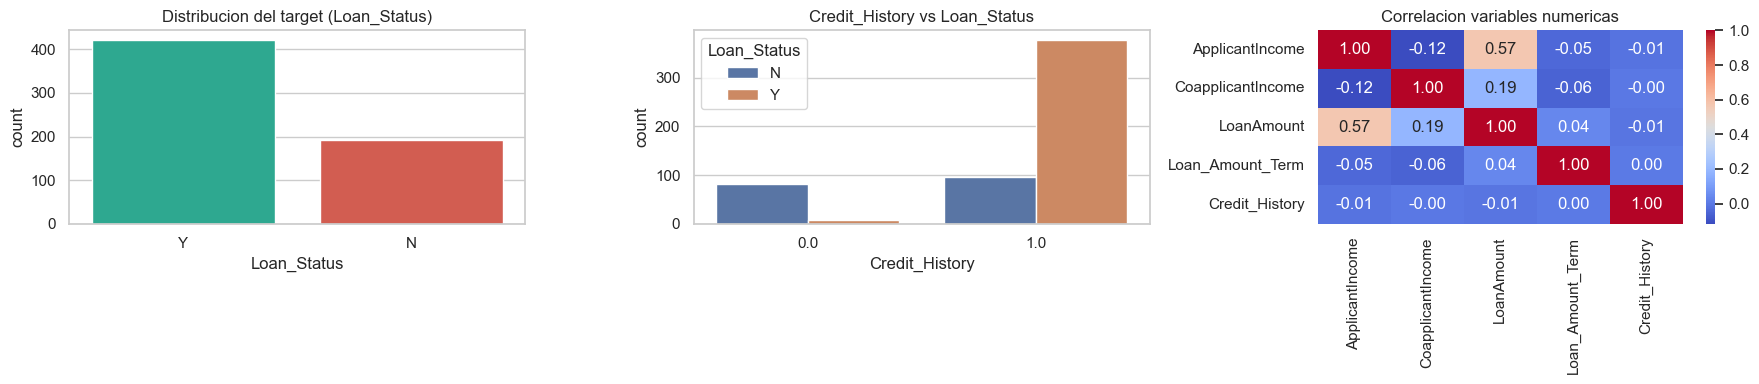

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) Distribución del target
sns.countplot(x="Loan_Status", data=df, ax=axes[0],
              palette=["#1abc9c", "#e74c3c"])
axes[0].set_title("Distribucion del target (Loan_Status)")

# 2) Credit_History vs Loan_Status
sns.countplot(x="Credit_History", hue="Loan_Status", data=df, ax=axes[1])
axes[1].set_title("Credit_History vs Loan_Status")

# 3) Correlación entre variables numéricas
corr = df[numericas].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2])
axes[2].set_title("Correlacion variables numericas")

plt.tight_layout()
plt.show()

**Lectura de los gráficos:**

- **Distribución del target:** hay 422 aprobados frente a 192 rechazados → **clases desbalanceadas** (más del doble de "Y"). Esto importa porque un modelo que prediga siempre "aprobado" ya acertaría ~69%; por eso no basta con mirar el accuracy.
- **Credit_History vs Loan_Status:** casi todos los aprobados tienen `Credit_History = 1.0`; cuando vale `0.0` la mayoría son rechazos. **Tener buen historial crediticio está fuertemente asociado a la aprobación.**
- **Correlación:** la más alta es `ApplicantIncome`–`LoanAmount` (0.57), lógico (quien gana más pide montos mayores). El resto son bajas, lo cual es bueno: las variables aportan información distinta.

## Parte 3 — Preparación de datos

### 3.1 Manejo de valores faltantes

Criterio de imputación:
- **Categóricas y `Credit_History`** → se rellenan con la **moda** (valor más frecuente), porque no existe un "promedio" de categorías. `Credit_History` es 0/1, en realidad categórica.
- **`LoanAmount`** → **mediana**, más robusta que la media frente a valores extremos (outliers).
- **`Loan_Amount_Term`** → **moda**, porque los plazos toman pocos valores típicos (ej. 360 meses).

In [11]:
df = df.drop(columns=["Loan_ID"])

for c in ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]:
    df[c] = df[c].fillna(df[c].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])

print("Nulos restantes:", df.isnull().sum().sum())

Nulos restantes: 0


### 3.2 Codificación de variables categóricas

Los modelos solo operan con números, así que convertimos cada categoría a un entero con `LabelEncoder` (ej. `Male→1`, `Female→0`). El target `Loan_Status` queda como `Y→1`, `N→0`.

In [12]:
cat_cols = ["Gender", "Married", "Dependents", "Education",
            "Self_Employed", "Property_Area", "Loan_Status"]

for c in cat_cols:
    df[c] = LabelEncoder().fit_transform(df[c])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


### 3.3 Separación X / y y división train/test

- **X** = variables predictoras; **y** = variable objetivo.
- `test_size=0.2` → 80% entrenamiento, 20% prueba (datos que el modelo nunca vio).
- `random_state=42` → resultado reproducible.
- `stratify=y` → mantiene la misma proporción Y/N en train y test, respetando el desbalance.

In [13]:
X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (491, 11)  Test: (123, 11)


## Parte 4 — Modelado

Entrenamos **dos modelos** para compararlos:

- **Regresión Logística:** modelo lineal, simple e interpretable. A pesar del nombre, es un **clasificador** (estima la probabilidad de pertenecer a la clase 1). Buena línea base.
- **Random Forest:** conjunto de muchos árboles de decisión que votan; captura relaciones no lineales y nos da la importancia de cada variable.

In [14]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


C:\Users\Juan Chavarro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Parte 5 — Evaluación

Como es clasificación, usamos: **Accuracy, Precision, Recall, F1-score** y la **matriz de confusión**.

- **Accuracy:** porcentaje total de aciertos.
- **Precision:** de los que predije como aprobados, ¿cuántos lo eran de verdad?
- **Recall:** de los que sí debían aprobarse, ¿cuántos detecté?
- **F1:** combina precision y recall (útil con clases desbalanceadas).

In [15]:
def evaluar(modelo, nombre):
    pred = modelo.predict(X_test)
    print(f"===== {nombre} =====")
    print("Accuracy :", round(accuracy_score(y_test, pred), 3))
    print("Precision:", round(precision_score(y_test, pred), 3))
    print("Recall   :", round(recall_score(y_test, pred), 3))
    print("F1-score :", round(f1_score(y_test, pred), 3))
    print("Matriz de confusion:")
    print(confusion_matrix(y_test, pred))
    print()
    return pred

pred_lr = evaluar(log_reg, "Regresion Logistica")
pred_rf = evaluar(rf, "Random Forest")

===== Regresion Logistica =====
Accuracy : 0.862
Precision: 0.84
Recall   : 0.988
F1-score : 0.908
Matriz de confusion:
[[22 16]
 [ 1 84]]

===== Random Forest =====
Accuracy : 0.829
Precision: 0.848
Recall   : 0.918
F1-score : 0.881
Matriz de confusion:
[[24 14]
 [ 7 78]]



### Matriz de confusión visual (mejor modelo: Regresión Logística)

Lectura: filas = valor real, columnas = predicción. La diagonal son los aciertos.

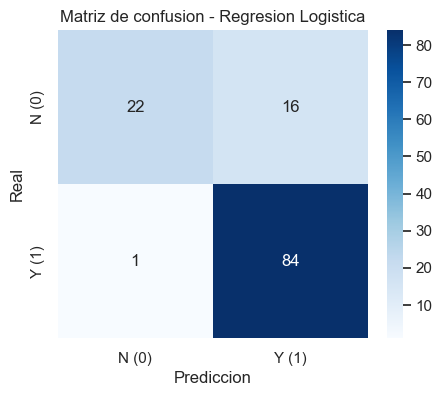

In [16]:
cm = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["N (0)", "Y (1)"],
            yticklabels=["N (0)", "Y (1)"])
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion - Regresion Logistica")
plt.show()

### Importancia de variables (Random Forest)

Random Forest permite ver qué variables pesaron más en la predicción.

C:\Users\Juan Chavarro\AppData\Local\Temp\ipykernel_8156\1062372776.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette="viridis")


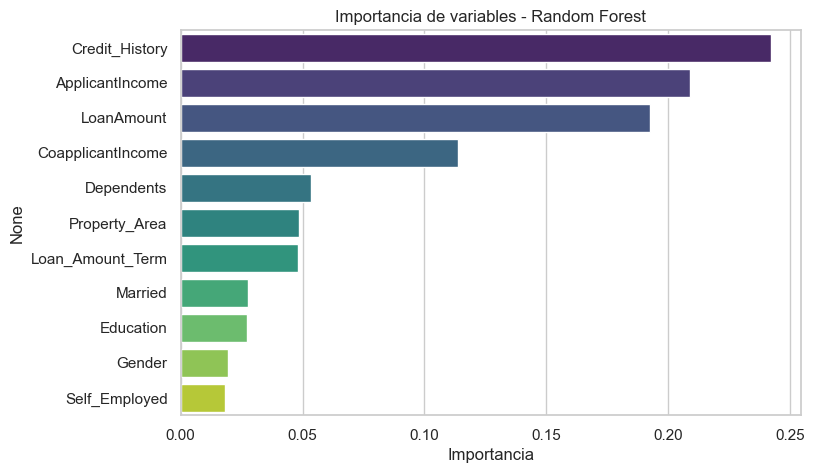

Credit_History       0.242
ApplicantIncome      0.209
LoanAmount           0.193
CoapplicantIncome    0.114
Dependents           0.053
Property_Area        0.048
Loan_Amount_Term     0.048
Married              0.028
Education            0.027
Gender               0.019
Self_Employed        0.018
dtype: float64


In [17]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, palette="viridis")
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.show()

print(importancias.round(3))

## Parte 6 — Interpretación

**¿Qué tan bueno es el modelo?**
La **Regresión Logística** logra ~**86% de accuracy** y **F1 de 0.91**, superando a Random Forest. Su punto fuerte es que casi no deja escapar aprobaciones válidas (recall ~0.99). Su debilidad: comete falsos positivos en los rechazos (aprueba a algunos que debían negarse), que es justo el error costoso para un banco.

**¿Qué variable influye más?**
**`Credit_History`** es la más influyente, seguida de `ApplicantIncome` y `LoanAmount`. Coincide con el EDA: el historial crediticio es el factor decisivo, lo cual tiene sentido de negocio.

**¿Qué mejoraría con más tiempo?**
- **Escalar las variables numéricas** (`StandardScaler`): mejora la convergencia de la Regresión Logística.
- **Atacar el desbalance** con `class_weight="balanced"` o sobremuestreo (SMOTE) para reducir falsos positivos en los rechazos.
- **Ingeniería de variables**: crear `TotalIncome = ApplicantIncome + CoapplicantIncome` o el ratio ingreso/monto.
- **Ajuste de hiperparámetros** con validación cruzada (`GridSearchCV`) en vez de una sola división train/test, para una estimación más estable.